In [1]:
from models.nsf import SplineFlowWindow
import numpy as np
from network_test import _sims_to_tensors, compute_stats
from torch.utils.data import TensorDataset
import torch

In [22]:
data = np.load("dataset.npz")
foot = data["foot"]
com = data["com"]
stats = compute_stats("dataset.npz")
S = foot.shape[0]
rng = np.random.default_rng(0)
perm = rng.permutation(S)
train_idx = perm[:int(0.7 * S)]
test_idx  = perm[int(0.7 * S):]
foot_windows, coms = _sims_to_tensors(foot, com, np.arange(S), stats)
foot_windows_train, coms_train = _sims_to_tensors(foot, com, train_idx, stats)
foot_windows_test, coms_test = _sims_to_tensors(foot, com, test_idx, stats)


────────────────────────────────────────────────────────────
  Step 1/3 – computing normalisation stats
────────────────────────────────────────────────────────────
  Dataset       : dataset.npz
  Window        : 15 frames = 300 ms
  Simulations   : 100,000   frames/sim : 39
  COM std       : [6. 4. 2.] cm


In [3]:
print("X mean:", foot_windows_train.mean().item())
print("X std :", foot_windows_train.std().item())

print("y mean:", coms_train.mean().item())
print("y std :", coms_train.std().item())
#(nsimulations x 36 (n windows per sample))x (window dim x 6foot dimensions)
#(nsimulations x 36) x (3 COM dimensions)
print("Foot windows shape:", foot_windows_train.shape)
print("COM shape:", coms_train.shape)

X mean: -0.005142764188349247
X std : 0.9543936848640442
y mean: -1.0208856676685585e-10
y std : 1.004450798034668
Foot windows shape: torch.Size([1750000, 90])
COM shape: torch.Size([1750000, 3])


In [5]:
print(f"COM: min={coms_train.min():.2f}, max={coms_train.max():.2f}")
print(f"Percentiles: 1%={torch.quantile(coms_train, 0.01):.2f}, 99%={torch.quantile(coms_train, 0.99):.2f}")

COM: min=-9.04, max=5.26
Percentiles: 1%=-2.28, 99%=1.94


In [6]:
print("Per-dimension stats:")
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train[:, i]
    print(f"  {dim}: min={col.min():.2f}, max={col.max():.2f}, "
          f"std={col.std():.2f}, "
          f"1%={torch.quantile(col, 0.01):.2f}, "
          f"99%={torch.quantile(col, 0.99):.2f}")

Per-dimension stats:
  x: min=-2.83, max=2.46, std=1.00, 1%=-1.91, 99%=1.74
  y: min=-9.04, max=3.66, std=0.99, 1%=-2.13, 99%=1.90
  z: min=-3.35, max=5.26, std=1.02, 1%=-2.52, 99%=2.63


In [5]:
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train[:, i]
    for thresh in [3.0, 4.0, 5.0]:
        n = (col.abs() > thresh).sum().item()
        print(f"  {dim}: {n} samples beyond ±{thresh} ({100*n/len(col):.3f}%)")

  x: 0 samples beyond ±3.0 (0.000%)
  x: 0 samples beyond ±4.0 (0.000%)
  x: 0 samples beyond ±5.0 (0.000%)
  y: 572 samples beyond ±3.0 (0.033%)
  y: 4 samples beyond ±4.0 (0.000%)
  y: 4 samples beyond ±5.0 (0.000%)
  z: 16666 samples beyond ±3.0 (0.952%)
  z: 6965 samples beyond ±4.0 (0.398%)
  z: 10 samples beyond ±5.0 (0.001%)


In [3]:
bad_mask = coms_train[:, 1].abs() > 5.0  # 4 samples with large vertical (y) COM values, likely artifacts
print(f"Dropping {bad_mask.sum()} bad frames")
coms_train_filtered = coms_train[~bad_mask]
windows_train_filtered = foot_windows_train[~bad_mask]
print(coms_train_filtered.shape, windows_train_filtered.shape)

Dropping 4 bad frames
torch.Size([1749996, 3]) torch.Size([1749996, 90])


In [6]:
# Run this before training, on your filtered data
print(f"COM filtered: min={coms_train_filtered.min():.4f}, max={coms_train_filtered.max():.4f}")
print("Per-dim:")
for i, dim in enumerate(['x', 'y', 'z']):
    col = coms_train_filtered[:, i]
    print(f"  {dim}: min={col.min():.4f}, max={col.max():.4f}")

COM filtered: min=-3.8079, max=5.2596
Per-dim:
  x: min=-2.8316, max=2.4624
  y: min=-3.8079, max=3.6613
  z: min=-3.3525, max=5.2596


In [4]:
#I also need to apply filter from training data to test data
#he test set should never be filtered based on its own statistics, apply the exact same thresholds derived from the training set
bad_mask = coms_test[:, 1].abs() > 5.0  
print(f"Dropping {bad_mask.sum()} bad frames")
coms_test_filtered = coms_test[~bad_mask]
windows_test_filtered = foot_windows_test[~bad_mask]
print(coms_test_filtered.shape, windows_test_filtered.shape)

Dropping 2 bad frames
torch.Size([749998, 3]) torch.Size([749998, 90])


In [5]:
TAILBOUND = float(coms_train_filtered.abs().max()) * 1.1

In [6]:
train_dataset = TensorDataset(windows_train_filtered, coms_train_filtered)
test_dataset = TensorDataset(windows_test_filtered, coms_test_filtered)

In [9]:
print(f"TAILBOUND: {TAILBOUND}")
print(f"train dataset COM: min={train_dataset.tensors[1].min():.4f}, max={train_dataset.tensors[1].max():.4f}")
print(f"test dataset COM: min={test_dataset.tensors[1].min():.4f}, max={test_dataset.tensors[1].max():.4f}")

TAILBOUND: 5.785606336593628
train dataset COM: min=-3.8079, max=5.2596
test dataset COM: min=-3.7623, max=5.1644


In [7]:
train_max = float(coms_train_filtered.abs().max())
print(f"train max abs: {train_max:.4f}")
print(f"TAILBOUND: {TAILBOUND:.4f}")
print(f"test max abs: {float(coms_test_filtered.abs().max()):.4f}")

train max abs: 5.2596
TAILBOUND: 5.7856
test max abs: 5.1644


In [8]:
model = SplineFlowWindow(
    window_dim=90,
    blocks=6,
    num_bins=10,
    tail_bound=TAILBOUND
).to("cuda")

In [ ]:
from models.nsf import train_inn_cond3D

In [10]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim, mode="min", factor=0.5, patience=10
)

history = train_inn_cond3D(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    optim=optim,
    epochs=200,
    batch_size=256,
    shuffle=True,
    lr_scheduler=scheduler,
)

torch.save({
    'model_state_dict': model.state_dict(),
    'window_dim': 90,
    'blocks': 6,
    'num_bins': 10,
    'history': history,
}, "nsf_window.pt")

Training: 100%|██████████| 200/200 [8:41:28<00:00, 156.44s/it, test_loss=-7.22, train_loss=-7.31]  


In [7]:
checkpoint = torch.load("nsf_window.pt", map_location="cpu")
finalmodel = SplineFlowWindow(
    window_dim=90,
    blocks=6,
    num_bins=10,
    tail_bound=TAILBOUND
).to("cpu")
finalmodel.load_state_dict(checkpoint['model_state_dict'])
finalmodel.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (coupling_blocks): ModuleList(
      (0-5): 6 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=31, bias=True)
        )
      )
    )
    (linear_blocks): ModuleList(
      (0-4): 5 x InvertibleLinear()
    )
  )
)

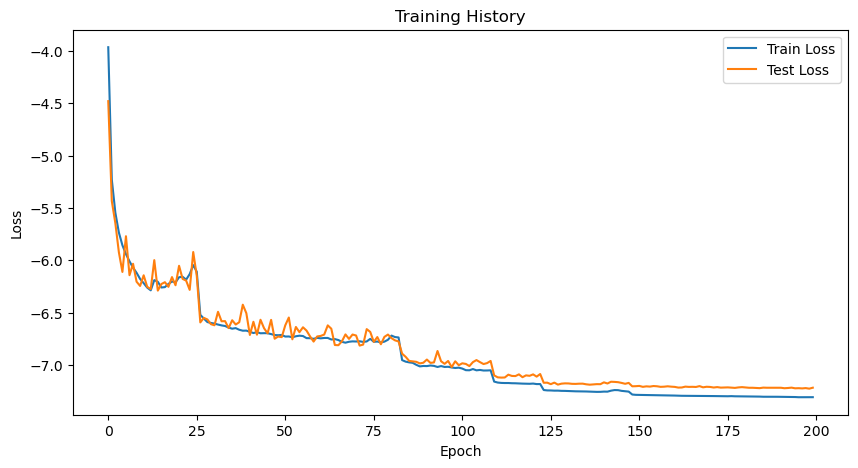

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(checkpoint["history"]['train_loss'], label='Train Loss')
plt.plot(checkpoint["history"]['test_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()

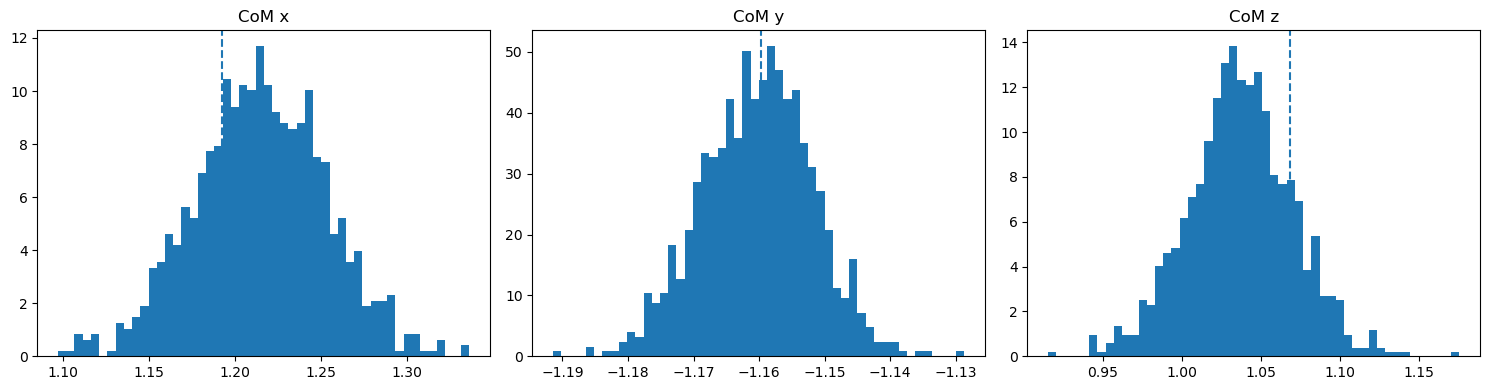

In [12]:
window, com = test_dataset[200]
window = window.unsqueeze(0).to("cpu")        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to("cpu") 
com = com.cpu().numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = finalmodel.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].cpu().numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

#### MODEL HYPERPARMATER SELECTION

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model_1 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=256, num_bins=10).to(device)
optimizer = torch.optim.Adam(model_1.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_1,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_1.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 256,
    "num_bins": 10,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{1}.pt")

Training:   2%|▏         | 1/50 [07:16<5:56:48, 436.91s/it, test_loss=-7.72, train_loss=-7.17]


KeyboardInterrupt: 

In [ ]:
model_2 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=512, num_bins=10).to(device)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_2,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_2.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 512,
    "num_bins": 10,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{2}.pt")

In [ ]:
model_3 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=4, tail_bound=TAILBOUND, hidden_size=256, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_3,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_3.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 4,
    "hidden_size": 256,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{3}.pt")

In [ ]:
model_4 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=5, tail_bound=TAILBOUND, hidden_size=512, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_4,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_4.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 5,
    "hidden_size": 512,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{4}.pt")

In [ ]:
model_5 = SplineFlowWindow(window_dim=windows_train_filtered.shape[1], blocks=6, tail_bound=TAILBOUND, hidden_size=512, num_bins=12).to(device)
optimizer = torch.optim.Adam(model_5.parameters(), lr=1e-3)
history = train_inn_cond3D(
    model_5,
    train_dataset,
    test_dataset,
    optim=optimizer,
    epochs=50,
    batch_size=128
)

torch.save({
        "model_state": model_5.state_dict(),
        "config": {
    "window_dim": windows_train_filtered.shape[1],
    "blocks": 6,
    "hidden_size": 512,
    "num_bins": 12,
    "epochs": 50,
    "batch_size": 128,
    "lr": 1e-3
}
    }, f"slidingwindow_{5}.pt")

In [11]:
model_1 = torch.load(f"slidingwindow_1conhistory.pt", map_location=device)

#### Model evaluation

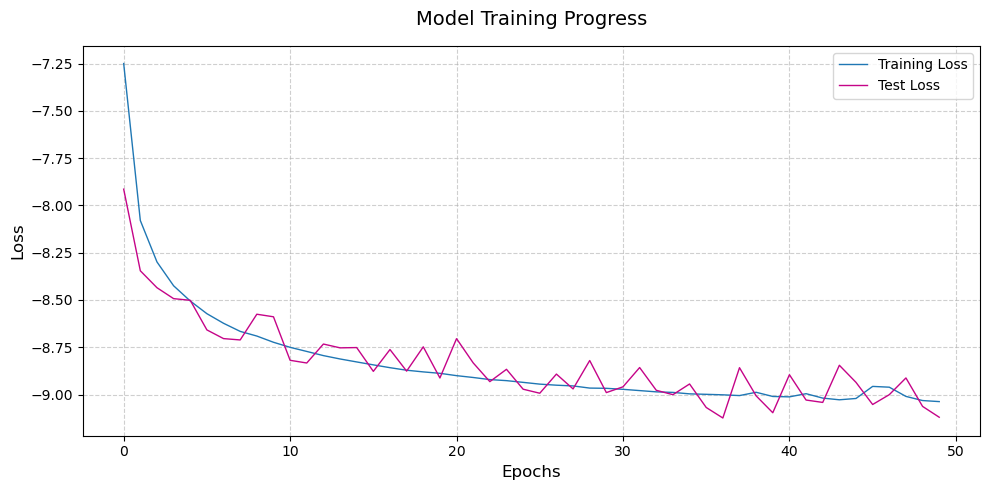

In [13]:
import matplotlib.pyplot as plt
history = model_1["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [14]:
model = SplineFlowWindow(model_1["config"]["window_dim"], blocks=model_1["config"]["blocks"], tail_bound=5.7856, hidden_size=model_1["config"]["hidden_size"], num_bins=model_1["config"]["num_bins"]).to(device)
model.load_state_dict(model_1["model_state"])
model.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-3): 4 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=31, bias=True)
        )
      )
    )
  )
)

In [ ]:
x, y = train_dataset[0]
x = x.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
theta = y.unsqueeze(0).to(device) # shape [1, theta_dim]

with torch.no_grad():
    output = model(x, theta)
with torch.no_grad():
    out = model(x, theta) 
print(out.shape)

torch.Size([1, 3])


#### Internal validation

##### Sample from posterior

Visualize posterior for one window

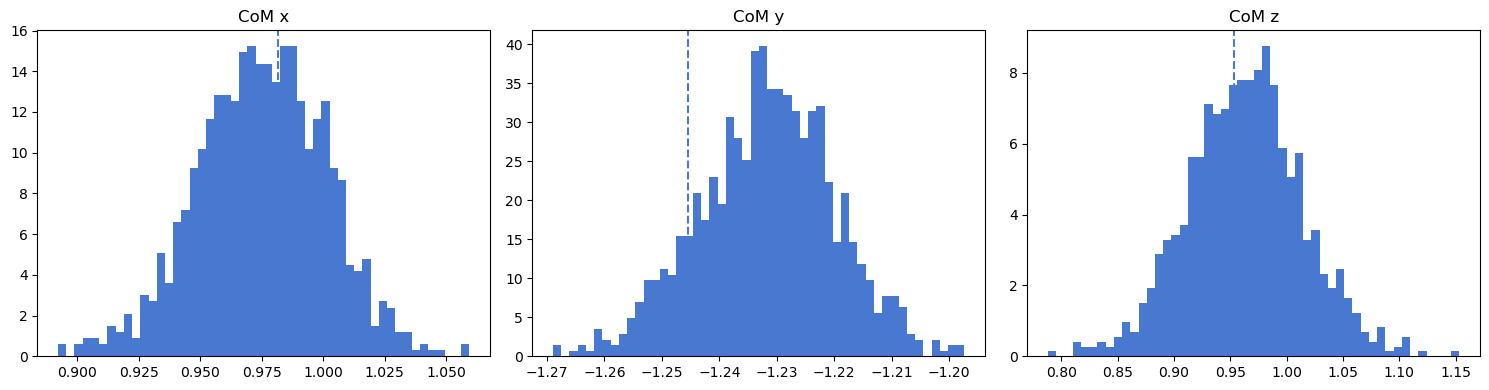

In [15]:
window, com = test_dataset[100]
window = window.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to(device) 
com = com.numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = model.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [15]:
model_2 = torch.load(f"slidingwindow_2.pt", map_location=device)

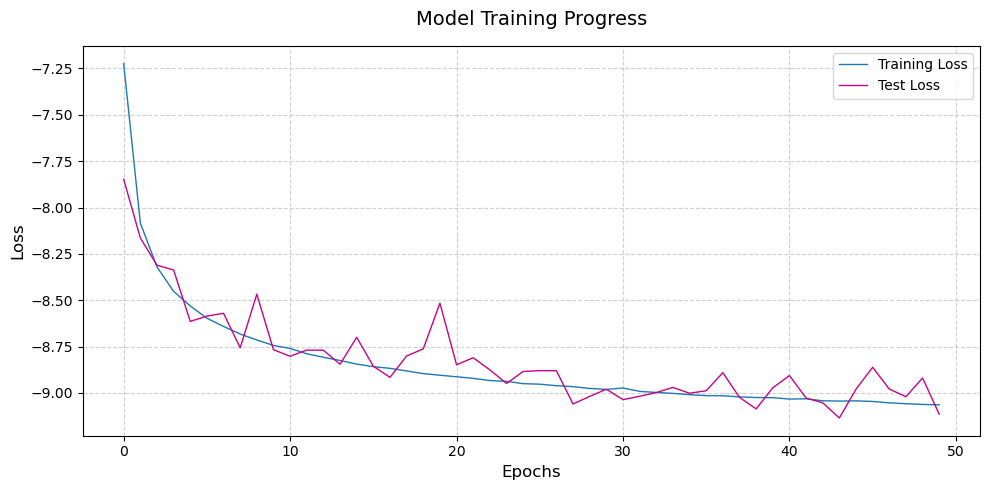

In [20]:
import matplotlib.pyplot as plt
history = model_2["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [16]:
model2 = SplineFlowWindow(model_2["config"]["window_dim"], blocks=model_2["config"]["blocks"], tail_bound=5.7856, hidden_size=model_2["config"]["hidden_size"], num_bins=model_2["config"]["num_bins"]).to(device)
model2.load_state_dict(model_2["model_state"])
model2.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-3): 4 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
          (3): ReLU()
          (4): Linear(in_features=512, out_features=31, bias=True)
        )
      )
    )
  )
)

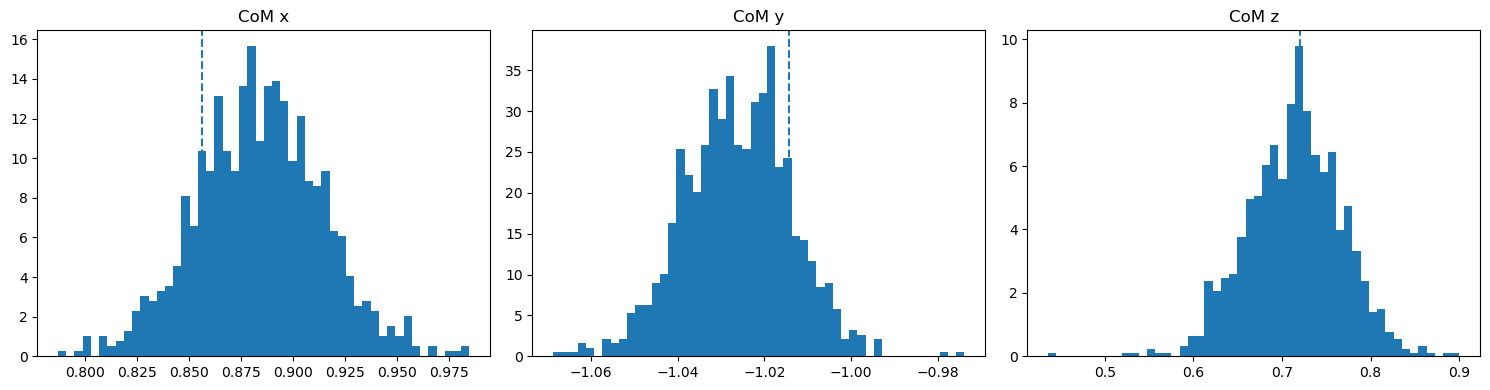

In [17]:
window, com = test_dataset[50]
window = window.unsqueeze(0).to(device)        # shape [1, window_dim], before [window_dim]
com = com.unsqueeze(0).to(device) 
com = com.numpy().flatten()
n_samples = 1000
with torch.no_grad():
    samples = model2.sample(window, n_samples) 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x", "CoM y", "CoM z"]

for d in range(3):
    axes[d].hist(samples[:, d].numpy(), bins=50, density=True)
    axes[d].axvline(com[d].item(), linestyle="--")
    axes[d].set_title(labels[d])

plt.tight_layout()
plt.show()

In [22]:
model_3 = torch.load(f"slidingwindow_3.pt", map_location=device)
model3 = SplineFlowWindow(model_3["config"]["window_dim"], blocks=model_3["config"]["blocks"], tail_bound=5.7856, hidden_size=model_3["config"]["hidden_size"], num_bins=model_3["config"]["num_bins"]).to(device)
model3.load_state_dict(model_3["model_state"])
model3.eval()
print(model_3["config"])

{'window_dim': 90, 'blocks': 4, 'hidden_size': 256, 'num_bins': 12, 'epochs': 50, 'batch_size': 128, 'lr': 0.001, 'history': {'train_loss': [-7.234102828367194, -8.071454045309878, -8.296144651079828, -8.424555415234417, -8.514510055195172, -8.583998591920924, -8.638683477620079, -8.666416153342077, -8.708265473598322, -8.736719753864076, -8.760441073770272, -8.788122290152671, -8.807386793187636, -8.828238403123935, -8.845794919604174, -8.860222379748844, -8.871895184119882, -8.881798052192195, -8.89539227575433, -8.905832572233571, -8.916873757005565, -8.921618901843397, -8.93270890091197, -8.936988951660434, -8.950127136575999, -8.953584467531012, -8.958539501483408, -8.966336614164911, -8.975377318257461, -8.97620177015195, -8.988065383626987, -8.993672445428201, -8.992008037026148, -9.003271339292795, -9.006457254132782, -9.008940744092778, -9.018439397692239, -9.019513020178406, -9.0223749262604, -9.02823580462513, -9.030459891240826, -9.038016023513118, -9.041073191866985, -9.04

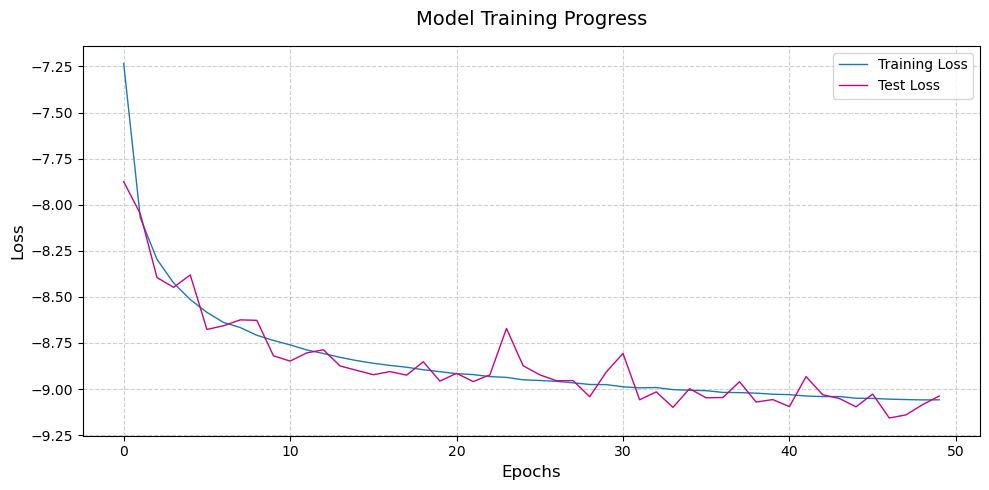

In [26]:
import matplotlib.pyplot as plt
history = model_3["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [24]:
model_4 = torch.load(f"slidingwindow_4.pt", map_location=device)
model4 = SplineFlowWindow(model_4["config"]["window_dim"], blocks=model_4["config"]["blocks"], tail_bound=5.7856, hidden_size=model_4["config"]["hidden_size"], num_bins=model_4["config"]["num_bins"]).to(device)
model4.load_state_dict(model_4["model_state"])
model4.eval()

SplineFlowWindow(
  (flow): SplineFlow3D(
    (blocks): ModuleList(
      (0-4): 5 x SplineCouplingBlock3D(
        (param_net): Sequential(
          (0): Linear(in_features=92, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=512, bias=True)
          (3): ReLU()
          (4): Linear(in_features=512, out_features=37, bias=True)
        )
      )
    )
  )
)

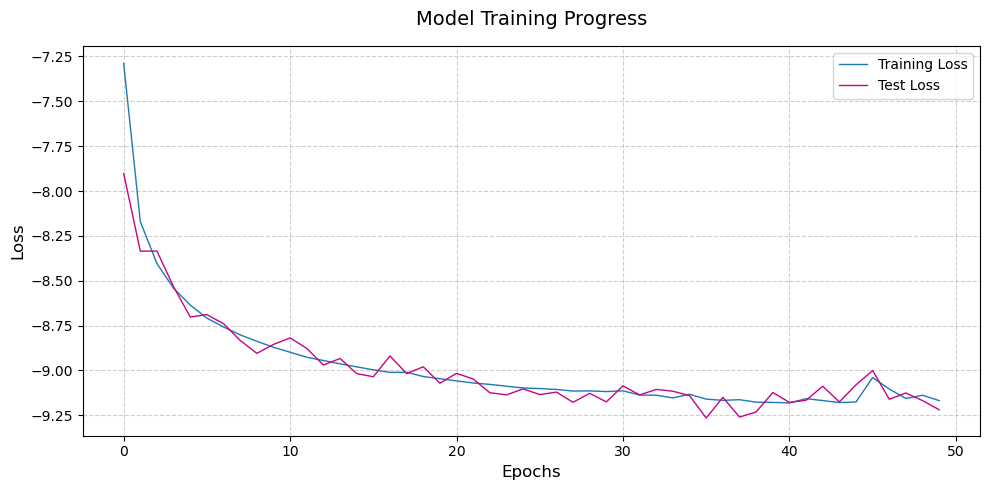

In [27]:
import matplotlib.pyplot as plt
history = model_4["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
# window_dim=90, hidden_size=256, blocks=4, num_bins=10, tail_bound=6.0

In [29]:
model_1 = torch.load(f"windowencoder_1.pt", map_location=device)
model1 = SplineFlowWindow(model_1["config"]["window_dim"], blocks=model_1["config"]["blocks"], tail_bound=TAILBOUND, hidden_size=model_1["config"]["hidden_size"], num_bins=model_1["config"]["num_bins"]).to(device)
model1.load_state_dict(model_1["model_state"])
model1.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'windowencoder_1.pt'

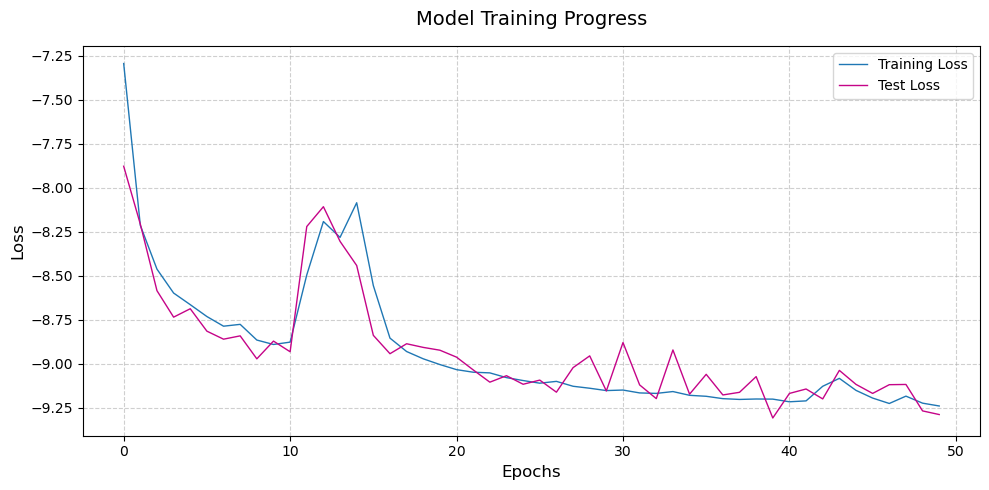

In [28]:
import matplotlib.pyplot as plt
history = model_5["config"]["history"]
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

#### INTERNAL VALIDATION

each slide window

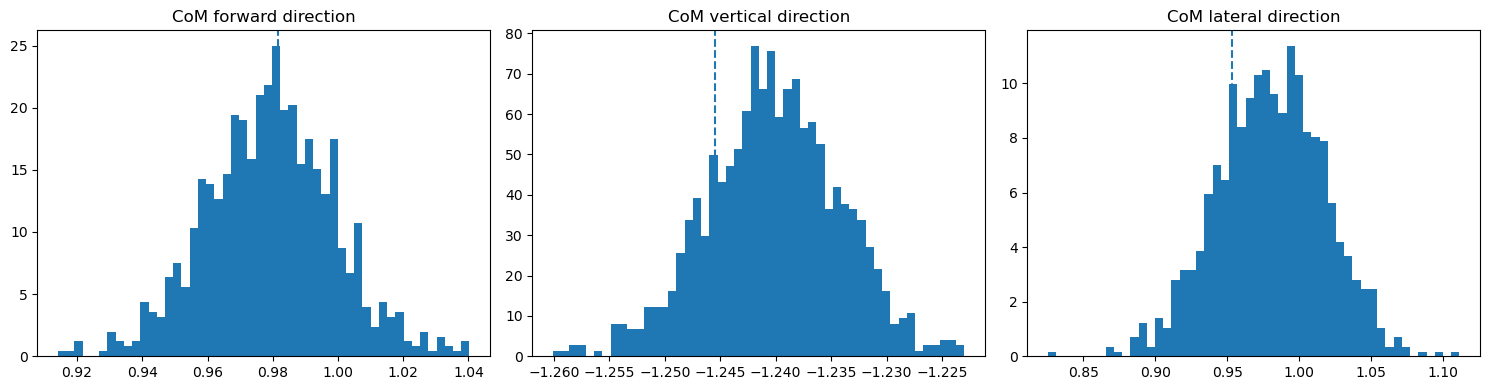

In [8]:
from internal_validation import plot_posterior_samples
plot_posterior_samples(finalmodel, test_dataset, n_samples=1000, idx=100)

Energy error: 0.0306
Mean l2 error: 0.0432


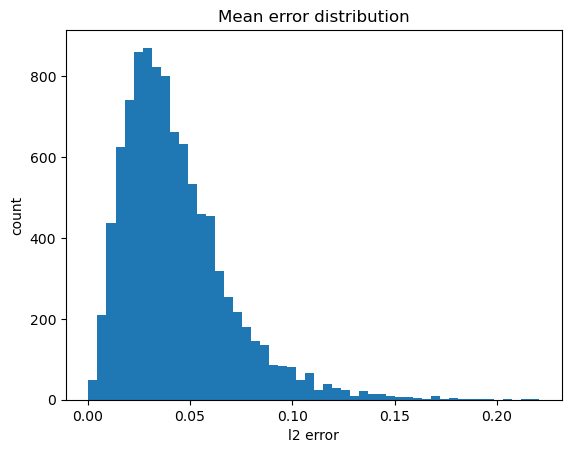

Mean error: 0.0432


In [14]:
from internal_validation import evaluate_energy, evaluate_mean_error
from torch.utils.data import Subset
test_dataset_10k = Subset(test_dataset, range(10000))
energy_error = evaluate_energy(finalmodel, test_dataset_10k, n_samples=500)
print(f"Energy error: {energy_error:.4f}")
mean_error, error_perwindow = evaluate_mean_error(finalmodel, test_dataset_10k, n_samples=500)
print(f"Mean error: {mean_error:.4f}")

trajectory of windows

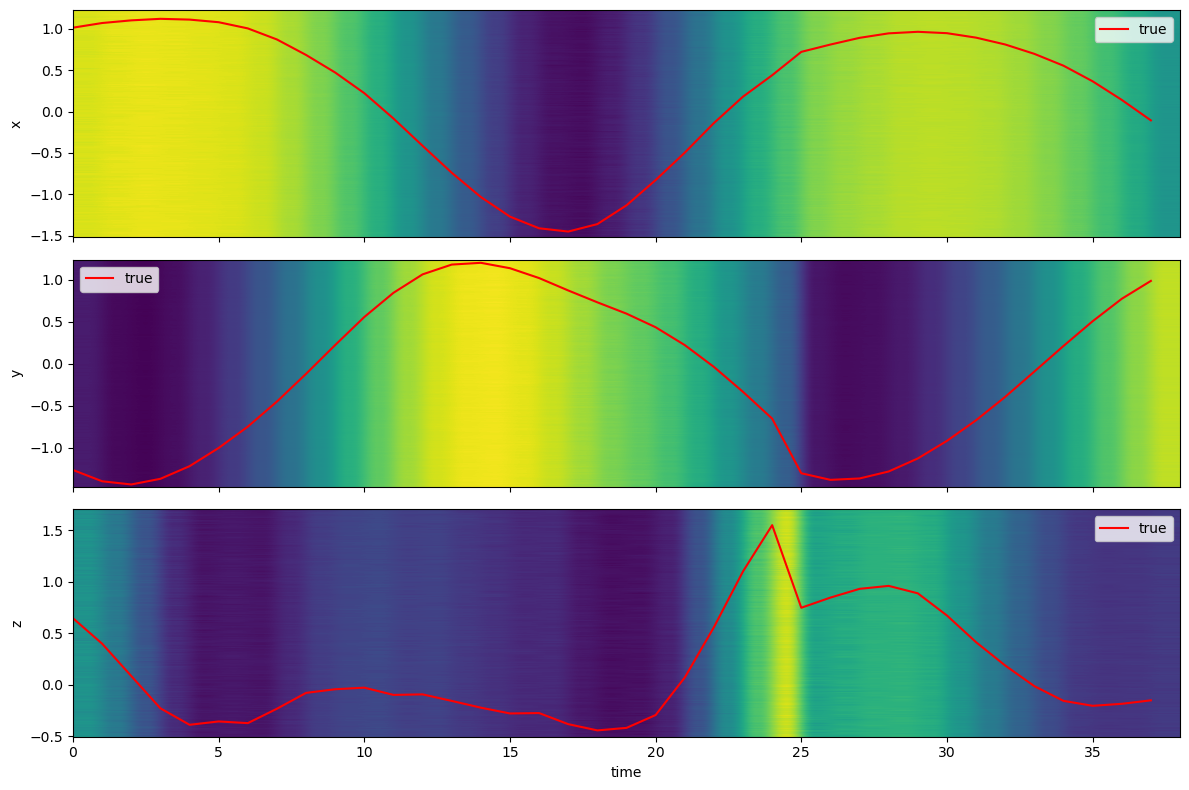

In [25]:
from internal_validation import get_posterior_samples_over_time, plot_trajectory_density
samples_over_time = get_posterior_samples_over_time(finalmodel, foot_windows[:38], n_samples=1000)
plot_trajectory_density(coms[:38], samples_over_time)

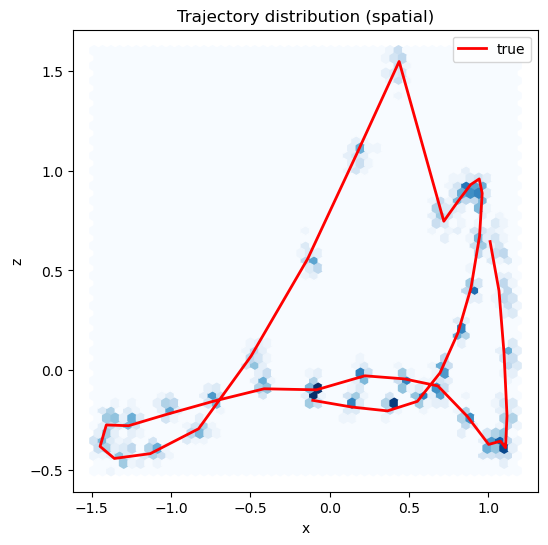

In [28]:
from internal_validation import sample_trajectory_paths, plot_spatial_trajectory_density
trajs = sample_trajectory_paths(samples_over_time, 40)
plot_spatial_trajectory_density(coms[:38], trajs)

think about stealing plots from david

need to be able to compute mean error along trajectories, energy score across all trajectories in test set.